In [2]:
"""
==========================================================
SmartFLEX TRL3 - User-Technology Flexibility Digital Twin
==========================================================

TRL3 proof-of-concept implementation.

The model combines:
    1. Technical resource characteristics
    2. User behavioural characteristics
    3. User comfort / operational constraints
    4. Uncertainty in user response
    5. Monte-Carlo simulation
    6. Probabilistic flexibility envelopes

Outputs:
    - technical flexibility
    - user-acceptable flexibility
    - deliverable flexibility
    - probability of successful delivery
    - probabilistic flexibility envelope
    - day-ahead flexibility prediction
    - validation metrics against observed flexibility

This is NOT a TRL7 control/market platform. It is the core
user-aware flexibility Digital Twin proof of concept.
"""

from dataclasses import dataclass
from typing import Dict, List, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# 1. DATA MODELS
# ============================================================

@dataclass
class FlexibleResource:
    """
    Technical characteristics of a flexible energy resource.
    """

    name: str
    rated_power_kw: float

    # Fraction of rated power that can actually be curtailed
    max_flex_fraction: float

    # Maximum continuous flexibility duration
    max_duration_hours: float

    # Minimum time before resource can respond
    response_time_minutes: float

    # Minimum time between flexibility activations
    recovery_time_hours: float

    # Whether the load can be interrupted
    interruptible: bool = True

    # Minimum operating level as fraction of rated power
    minimum_operating_fraction: float = 0.0


@dataclass
class UserFlexibilityProfile:
    """
    Behavioural/user characteristics obtained from questionnaire,
    interviews or observations.
    """

    user_id: str

    # Probability that user accepts a flexibility request
    acceptance_probability: float

    # Probability that user overrides an automated control action
    override_probability: float

    # Maximum acceptable interruption duration
    max_interruption_minutes: float

    # Maximum acceptable number of activations per day
    max_daily_events: int

    # Fraction of technically available flexibility the user
    # is normally willing to provide.
    willingness_fraction: float

    # Comfort sensitivity, 0 = insensitive, 1 = very sensitive
    comfort_sensitivity: float

    # Preference for automation:
    # 0 = manual, 1 = fully automated
    automation_preference: float


@dataclass
class FlexibilityEnvelope:
    """
    Probabilistic flexibility envelope.
    """

    time_index: pd.DatetimeIndex

    mean_kw: np.ndarray
    p10_kw: np.ndarray
    p50_kw: np.ndarray
    p90_kw: np.ndarray

    probability_of_delivery: np.ndarray

In [4]:
# ============================================================
# 2. DIGITAL TWIN
# ============================================================

class SmartFLEXDigitalTwin:
    """
    User-technology flexibility Digital Twin.

    The twin combines:

        Technical flexibility
                  +
        User acceptable flexibility
                  +
        Behavioural uncertainty
                  =
        Deliverable flexibility
    """

    def __init__(
        self,
        resource: FlexibleResource,
        user: UserFlexibilityProfile,
        random_seed: int = 42,
    ):

        self.resource = resource
        self.user = user

        self.rng = np.random.default_rng(random_seed)

    # --------------------------------------------------------
    # Technical flexibility
    # --------------------------------------------------------

    def technical_flexibility(
        self,
        baseline_kw: np.ndarray,
    ) -> np.ndarray:
        """
        Calculates technically available flexibility.

        Flexibility is represented as load reduction in kW.
        """

        max_reduction = (
            self.resource.rated_power_kw
            * self.resource.max_flex_fraction
        )

        minimum_load = (
            self.resource.rated_power_kw
            * self.resource.minimum_operating_fraction
        )

        technical = np.minimum(
            np.maximum(baseline_kw - minimum_load, 0),
            max_reduction,
        )

        return technical

    # --------------------------------------------------------
    # User acceptable flexibility
    # --------------------------------------------------------

    def user_acceptable_flexibility(
        self,
        technical_kw: np.ndarray,
        event_duration_minutes: float,
    ) -> np.ndarray:
        """
        Applies behavioural and comfort constraints.

        This converts technical flexibility into flexibility
        that the user is willing to provide.
        """

        # Duration constraint
        duration_factor = min(
            1.0,
            self.user.max_interruption_minutes
            / max(event_duration_minutes, 1.0),
        )

        # Comfort constraint
        comfort_factor = 1.0 - (
            0.5 * self.user.comfort_sensitivity
        )

        # Willingness constraint
        acceptable_fraction = (
            self.user.willingness_fraction
            * duration_factor
            * comfort_factor
        )

        acceptable_fraction = np.clip(
            acceptable_fraction,
            0.0,
            1.0,
        )

        return technical_kw * acceptable_fraction

    # --------------------------------------------------------
    # Probability of successful delivery
    # --------------------------------------------------------

    def delivery_probability(
        self,
        event_duration_minutes: float,
    ) -> float:
        """
        Estimates probability that a requested flexibility
        event will actually be delivered.

        The model accounts for:
            - acceptance
            - override
            - comfort
            - duration
            - automation preference
        """

        acceptance = self.user.acceptance_probability

        override_factor = 1.0 - self.user.override_probability

        duration_factor = min(
            1.0,
            self.user.max_interruption_minutes
            / max(event_duration_minutes, 1.0),
        )

        comfort_factor = 1.0 - (
            0.3 * self.user.comfort_sensitivity
        )

        automation_factor = (
            0.7
            + 0.3 * self.user.automation_preference
        )

        probability = (
            acceptance
            * override_factor
            * duration_factor
            * comfort_factor
            * automation_factor
        )

        return float(np.clip(probability, 0.0, 1.0))

    # --------------------------------------------------------
    # Monte Carlo flexibility simulation
    # --------------------------------------------------------

    def monte_carlo_flexibility(
        self,
        baseline_kw: np.ndarray,
        event_duration_minutes: float,
        n_simulations: int = 5000,
    ) -> FlexibilityEnvelope:
        """
        Generates a probabilistic flexibility envelope.

        Each Monte-Carlo realization represents one possible
        user response to a flexibility request.
        """

        technical = self.technical_flexibility(
            baseline_kw
        )

        acceptable = self.user_acceptable_flexibility(
            technical,
            event_duration_minutes,
        )

        probability = self.delivery_probability(
            event_duration_minutes
        )

        n_steps = len(baseline_kw)

        simulations = np.zeros(
            (n_simulations, n_steps)
        )

        for simulation in range(n_simulations):

            # User accepts/rejects the event
            accepts = (
                self.rng.random() < probability
            )

            if not accepts:
                continue

            # Random variation in willingness
            behavioural_factor = self.rng.normal(
                loc=1.0,
                scale=0.12,
            )

            behavioural_factor = np.clip(
                behavioural_factor,
                0.0,
                1.2,
            )

            # Random variation in technical availability
            technical_factor = self.rng.normal(
                loc=1.0,
                scale=0.05,
            )

            technical_factor = np.clip(
                technical_factor,
                0.0,
                1.1,
            )

            simulations[simulation, :] = (
                acceptable
                * behavioural_factor
                * technical_factor
            )

        p10 = np.percentile(
            simulations,
            10,
            axis=0,
        )

        p50 = np.percentile(
            simulations,
            50,
            axis=0,
        )

        p90 = np.percentile(
            simulations,
            90,
            axis=0,
        )

        mean = np.mean(
            simulations,
            axis=0,
        )

        probability_curve = np.array(
            [
                np.mean(simulations[:, i] > 0)
                for i in range(n_steps)
            ]
        )

        time_index = pd.date_range(
            start="2026-01-01 00:00",
            periods=n_steps,
            freq="15min",
        )

        return FlexibilityEnvelope(
            time_index=time_index,
            mean_kw=mean,
            p10_kw=p10,
            p50_kw=p50,
            p90_kw=p90,
            probability_of_delivery=probability_curve,
        )

    # --------------------------------------------------------
    # Day-ahead prediction
    # --------------------------------------------------------

    def predict_day_ahead(
        self,
        baseline_kw: np.ndarray,
        event_duration_minutes: float = 60,
        n_simulations: int = 5000,
    ) -> pd.DataFrame:
        """
        Produces the day-ahead flexibility forecast.
        """

        envelope = self.monte_carlo_flexibility(
            baseline_kw=baseline_kw,
            event_duration_minutes=event_duration_minutes,
            n_simulations=n_simulations,
        )

        result = pd.DataFrame({
            "timestamp": envelope.time_index,
            "baseline_kw": baseline_kw,
            "flexibility_mean_kw": envelope.mean_kw,
            "flexibility_p10_kw": envelope.p10_kw,
            "flexibility_p50_kw": envelope.p50_kw,
            "flexibility_p90_kw": envelope.p90_kw,
            "probability_delivery":
                envelope.probability_of_delivery,
        })

        return result


In [5]:
# ============================================================
# 3. EXAMPLE USER + TECHNOLOGY
# ============================================================

resource = FlexibleResource(
    name="Heat Pump",
    rated_power_kw=8.0,

    # At most 75% of rated power can be curtailed
    max_flex_fraction=0.75,

    # Can provide flexibility for up to 2 hours
    max_duration_hours=2.0,

    response_time_minutes=5,

    recovery_time_hours=1.0,

    interruptible=True,

    # Keep at least 10% of rated power
    minimum_operating_fraction=0.10,
)


user = UserFlexibilityProfile(
    user_id="USER_001",

    # 85% chance of accepting a flexibility event
    acceptance_probability=0.85,

    # 10% probability of overriding automated control
    override_probability=0.10,

    # User accepts up to 60 minutes interruption
    max_interruption_minutes=60,

    # Maximum three events per day
    max_daily_events=3,

    # User is willing to provide 70% of available flexibility
    willingness_fraction=0.70,

    # Moderate comfort sensitivity
    comfort_sensitivity=0.30,

    # High preference for automation
    automation_preference=0.80,
)

In [6]:
# ============================================================
# 4. SYNTHETIC BASELINE LOAD
# ============================================================

def create_heat_pump_baseline(
    periods: int = 96,
    seed: int = 42,
) -> np.ndarray:
    """
    Creates a synthetic 24-hour heat-pump load profile.

    96 x 15-minute intervals = 24 hours.
    """

    rng = np.random.default_rng(seed)

    time = np.arange(periods)

    # Morning heating peak
    morning_peak = (
        2.5
        * np.exp(
            -0.5
            * ((time - 28) / 10) ** 2
        )
    )

    # Evening heating peak
    evening_peak = (
        3.5
        * np.exp(
            -0.5
            * ((time - 72) / 14) ** 2
        )
    )

    base_load = 1.5

    noise = rng.normal(
        0,
        0.25,
        periods,
    )

    baseline = (
        base_load
        + morning_peak
        + evening_peak
        + noise
    )

    return np.clip(
        baseline,
        0,
        8,
    )


baseline = create_heat_pump_baseline()

In [7]:
# ============================================================
# 5. RUN DIGITAL TWIN
# ============================================================

twin = SmartFLEXDigitalTwin(
    resource=resource,
    user=user,
    random_seed=42,
)


forecast = twin.predict_day_ahead(
    baseline_kw=baseline,
    event_duration_minutes=60,
    n_simulations=10000,
)


In [8]:
# ============================================================
# 6. PRINT RESULTS
# ============================================================

print("\nSMARTFLEX TRL3 DIGITAL TWIN")
print("=" * 60)

print(f"Resource: {resource.name}")
print(f"Rated power: {resource.rated_power_kw:.1f} kW")
print(f"User: {user.user_id}")

print("\nUser parameters")
print("-" * 60)
print(
    f"Acceptance probability: "
    f"{user.acceptance_probability:.2f}"
)
print(
    f"Override probability: "
    f"{user.override_probability:.2f}"
)
print(
    f"Willingness fraction: "
    f"{user.willingness_fraction:.2f}"
)

print("\nPredicted flexibility")
print("-" * 60)

print(
    f"Maximum technical flexibility: "
    f"{forecast['flexibility_p90_kw'].max():.2f} kW"
)

print(
    f"Median deliverable flexibility: "
    f"{forecast['flexibility_p50_kw'].max():.2f} kW"
)

print(
    f"Mean deliverable flexibility: "
    f"{forecast['flexibility_mean_kw'].max():.2f} kW"
)

print(
    f"Mean probability of delivery: "
    f"{forecast['probability_delivery'].mean():.2%}"
)


SMARTFLEX TRL3 DIGITAL TWIN
Resource: Heat Pump
Rated power: 8.0 kW
User: USER_001

User parameters
------------------------------------------------------------
Acceptance probability: 0.85
Override probability: 0.10
Willingness fraction: 0.70

Predicted flexibility
------------------------------------------------------------
Maximum technical flexibility: 2.90 kW
Median deliverable flexibility: 2.32 kW
Mean deliverable flexibility: 1.67 kW
Mean probability of delivery: 65.26%


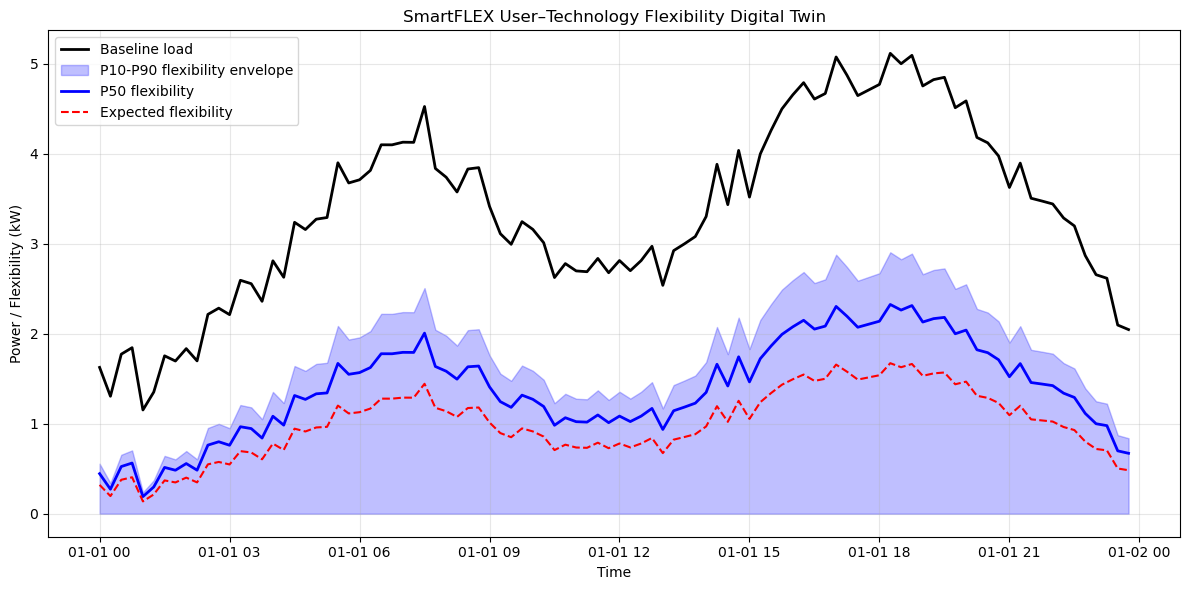

In [9]:
# ============================================================
# 7. FLEXIBILITY ENVELOPE PLOT
# ============================================================

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    forecast["timestamp"],
    forecast["baseline_kw"],
    label="Baseline load",
    color="black",
    linewidth=2,
)

plt.fill_between(
    forecast["timestamp"],
    forecast["flexibility_p10_kw"],
    forecast["flexibility_p90_kw"],
    alpha=0.25,
    color="blue",
    label="P10-P90 flexibility envelope",
)

plt.plot(
    forecast["timestamp"],
    forecast["flexibility_p50_kw"],
    color="blue",
    linewidth=2,
    label="P50 flexibility",
)

plt.plot(
    forecast["timestamp"],
    forecast["flexibility_mean_kw"],
    color="red",
    linestyle="--",
    label="Expected flexibility",
)

plt.xlabel("Time")
plt.ylabel("Power / Flexibility (kW)")
plt.title(
    "SmartFLEX User–Technology Flexibility Digital Twin"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# 8. VALIDATION AGAINST OBSERVED FLEXIBILITY
# ============================================================

def validate_prediction(
    predicted_kw: np.ndarray,
    observed_kw: np.ndarray,
) -> Dict[str, float]:
    """
    Basic TRL3 validation metrics.

    In the real SmartFLEX project, observed_kw would come from
    actual flexibility activation events at the pilot site.
    """

    predicted_kw = np.asarray(predicted_kw)
    observed_kw = np.asarray(observed_kw)

    mae = np.mean(
        np.abs(
            predicted_kw - observed_kw
        )
    )

    rmse = np.sqrt(
        np.mean(
            (
                predicted_kw - observed_kw
            ) ** 2
        )
    )

    denominator = np.sum(
        np.abs(observed_kw)
    )

    if denominator > 0:
        nmae = (
            np.sum(
                np.abs(
                    predicted_kw - observed_kw
                )
            )
            / denominator
        )
    else:
        nmae = np.nan

    return {
        "MAE_kW": float(mae),
        "RMSE_kW": float(rmse),
        "Normalized_MAE": float(nmae),
    }


In [11]:
# ============================================================
# 9. SYNTHETIC OBSERVED EVENT
# ============================================================

rng = np.random.default_rng(100)

# Simulate an observed flexibility activation
observed_flexibility = (
    forecast["flexibility_p50_kw"].values
    * rng.normal(
        1.0,
        0.10,
        len(forecast),
    )
)

observed_flexibility = np.clip(
    observed_flexibility,
    0,
    None,
)


validation = validate_prediction(
    predicted_kw=
        forecast["flexibility_mean_kw"].values,
    observed_kw=observed_flexibility,
)


print("\nValidation")
print("-" * 60)

for metric, value in validation.items():

    if "Normalized" in metric:
        print(
            f"{metric}: {value:.2%}"
        )
    else:
        print(
            f"{metric}: {value:.3f}"
        )


Validation
------------------------------------------------------------
MAE_kW: 0.387
RMSE_kW: 0.434
Normalized_MAE: 28.00%


In [12]:
# ============================================================
# 10. SAVE DIGITAL-TWIN OUTPUT
# ============================================================

forecast.to_csv(
    "smartflex_trl3_flexibility_forecast.csv",
    index=False,
)

print(
    "\nForecast saved to "
    "smartflex_trl3_flexibility_forecast.csv"
)


Forecast saved to smartflex_trl3_flexibility_forecast.csv
